<img src="https://i.postimg.cc/J7sf3Lq4/Group.png" alt="FUTURA" width="220" />

# Taller 3 — Web Scraping con **lxml + Requests**

En este taller vamos a:

1. **Configurar** un navegador automatizado (Chrome) controlado por Python.
2. **Inspeccionar** una página web (mi CV personal) y extraer datos específicos.
3. **Recorrer** múltiples páginas (Quotes to Scrape) navegando link por link.
4. **Almacenar** los resultados en un `DataFrame` de pandas para análisis.

> 💡 **Concepto clave:** Selenium **maneja un navegador real** (a diferencia de `requests`, que solo descarga HTML). Eso lo hace más lento, pero permite scrapear sitios con JavaScript, formularios, login, scroll infinito, etc.

In [2]:
#conda install lxml

In [1]:
from lxml import etree, html
import requests

In [2]:
# PETICIÓN HTTP (GET) -- requests.get(web)
response = requests.get('https://carlosrondanp.github.io/',headers=headers)
print(response.status_code) # 200 [OK]

NameError: name 'headers' is not defined

In [ ]:
# print(response.content)

In [7]:
# Capturamos el tree element (DOM)
tree = html.fromstring(response.content)
print(type(tree))
# tree (xlmx) ~  browser ~ driver (selenium)

<class 'lxml.html.HtmlElement'>


In [8]:
print(etree.tostring(tree, encoding = "unicode", pretty_print = True))

<html lang="es">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>Carlos Rondan | Data Scientist</title>
  <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&amp;display=swap" rel="stylesheet"/>
  <style>
    body {
      font-family: 'Inter', sans-serif;
      margin: 0;
      padding: 0;
      background-color: #f8f9fa;
      color: #212529;
    }
    .container {
      max-width: 900px;
      margin: 40px auto;
      padding: 20px;
      background-color: #fff;
      border-radius: 12px;
      box-shadow: 0 2px 10px rgba(0,0,0,0.05);
    }
    h1, h2, h3 {
      color: #111827;
    }
    h1 {
      font-size: 32px;
      margin-bottom: 0;
    }
    h2 {
      font-size: 24px;
      margin-top: 32px;
      border-bottom: 2px solid #e5e7eb;
      padding-bottom: 4px;
    }
    h3 {
      font-size: 18px;
      margin: 16px 0 4px;
    }
    .info, .section p {
      font-size: 16px;
      line-h

## 🔍 Comparativa: Selenium vs lxml + Requests

### 🌐 Caso 1: Automatización completa con Selenium

```python
# 📦 Importar librerías necesarias
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By

# ⚙️ Configuración del navegador
options = webdriver.ChromeOptions()
options.add_argument('--start-maximized')
options.add_argument('--disable-notifications')
options.add_argument('--no-sandbox')
options.add_argument('--verbose')
prefs = {"profile.default_content_setting_values.notifications": 2}
options.add_experimental_option("prefs", prefs)

# 🚀 Inicializar el navegador
driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

# 🌐 Acceder a la página
url = 'https://carlosrondanp.github.io/'
driver.get(url)

### 🧾 Caso 2: Extracción directa con lxml + Requests

```python

from lxml import html
import requests

# 🌐 Hacer la solicitud HTTP
response = requests.get('https://carlosrondanp.github.io/')
print(response.status_code)  # 200

# 🌳 Parsear HTML
tree = html.fromstring(response.content)

# Usar: User Agent en caso tengamos error:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36"
}
response = requests.get('https://carlosrondanp.github.io/', headers=headers)
print(response.status_code)  # 200


In [14]:
from lxml import html
import requests

response = requests.get('https://carlosrondanp.github.io/')
tree = html.fromstring(response.content)

In [ ]:
# Con SELENIUM
# nombre_xpath = "//h1[@id='nombre']"
# nombre = driver.find_element(By.XPATH, nombre_xpath).text

In [15]:
# tree.xpath()
nombre_xpath = "//h1[@id='nombre']"
nombre = tree.xpath(nombre_xpath)[0].text
nombre

'Carlos Enrique Rondan Poma'

In [19]:
#.get()
contacto_xpath = "//a[contains(text(), 'LinkedIn')]"
contacto = tree.xpath(contacto_xpath)[0].get('href')
contacto

'https://www.linkedin.com/in/carlosrondanp/'

# Caso práctico: IMDB

In [24]:
# Sin headers
url = 'https://www.imdb.com/es/'

from lxml import html
import requests

response = requests.get(url)
response.status_code



202

In [23]:
# Usar: User Agent en caso tengamos error:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36"
}



In [26]:
## Usando headers
url_root = 'https://www.imdb.com/es/'
response = requests.get(url_root, headers=headers)
print(response.status_code)
tree = html.fromstring(response.content)

202


ParserError: Document is empty

In [ ]:
mejores_pelis_xpath = r'//span[contains(text(), "Las 250")]/parent::a[1]'
root = tree.xpath(mejores_pelis_xpath)[0].get("href")

In [ ]:
url_root

In [ ]:
url_root[:-4]

In [ ]:
root

In [ ]:
url_movies = "https://www.imdb.com/es/chart/toptv/?ref_=hm_nv_menu"#url_root[:-4] + root
r = requests.get(url_movies, headers=headers)
print(r.status_code)
tree_top = html.fromstring(r.content)

In [ ]:
# print(etree.tostring(tree_top, encoding = "unicode", pretty_print = True))

In [ ]:
url_movies

In [ ]:
peliculas = tree_top.xpath(r"//div[contains(@class, 'cli-children')]")

In [ ]:
pelicula = peliculas[0]

In [ ]:
titulo = pelicula.xpath(r"./div[1]//h3")[0].text
metadata = '|'.join([meta.text for meta in pelicula.xpath(r"./div[2]//span[contains(@class, 'cli-title-metadata')]")])
tipo = pelicula.xpath(r"./div[2]//span[contains(@class, 'cli-title-type')]")[0].text

### Selenium

In [43]:
# IMPORTAR LIBRERÍAS
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By

In [44]:
# CONFIGURACIÓN DEL DRIVER
options = webdriver.ChromeOptions()
# options.add_argument('--incognito') # modo incógnito
options.add_argument('--start-maximized') # Abre en pantalla completa
options.add_argument('--disable-notifications') # Bloquea notificaciones emergentes
options.add_argument('--no-sandbox') # Mejora estabilidad en entornos virtuales
options.add_argument('--verbose') # Muestra información detallada del proceso
prefs = {"profile.default_content_setting_values.notifications" : 2} # Desactiva notificaciones

options.add_experimental_option("prefs",prefs)

driver = webdriver.Chrome(service = Service(ChromeDriverManager().install()),
                            options = options)

In [45]:
# Ingresamos a la web
url = 'https://www.imdb.com/es/'
driver.get(url)

In [47]:
mejores_pelis_xpath = r'//span[contains(text(), "Las 250")]/parent::a[1]'
root = driver.find_element(By.XPATH, mejores_pelis_xpath).get_attribute("href")

In [48]:
driver.get(root)

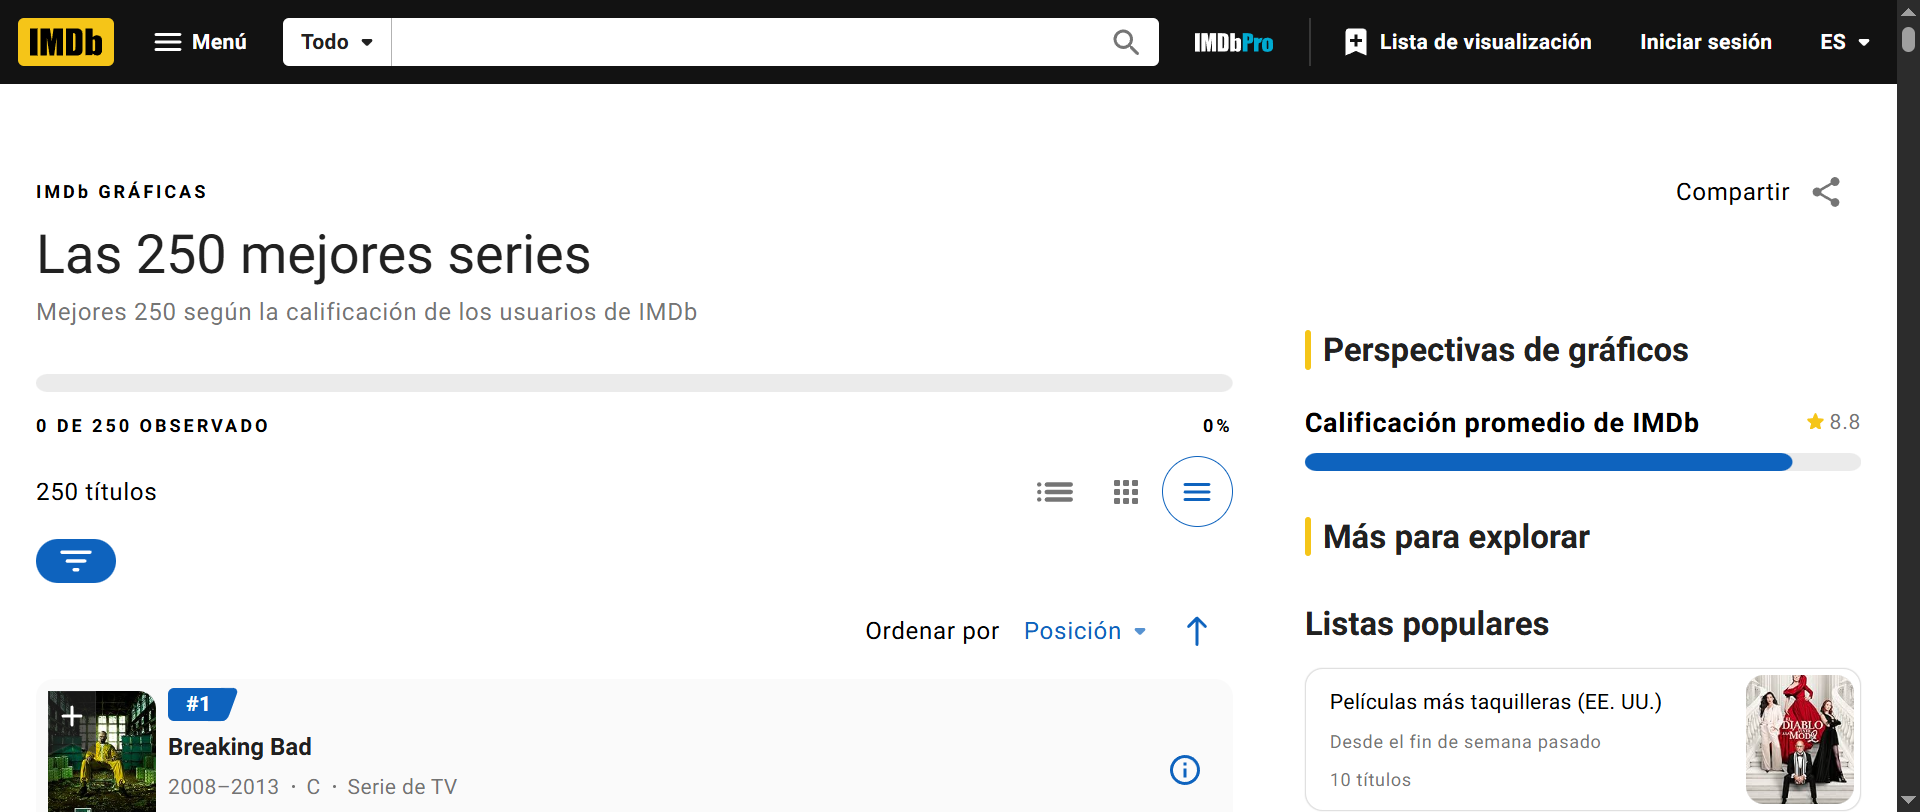

In [49]:
 from IPython.display import Image
 imagen_name = '250.png'
 driver.save_screenshot(f'{imagen_name}.png')
 Image(f'{imagen_name}.png')

#### Adicionales:
```python
# Scroll hacia el final de la página
driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

# Scroll hacia una posición específica en píxeles
driver.execute_script("window.scrollTo(0, 500);")  # 500 píxeles verticales

# Scroll hacia un elemento
elemento = driver.find_element(By.XPATH, '//footer')  # por ejemplo, hacia el footer
driver.execute_script("arguments[0].scrollIntoView();", elemento)    

# Zoom al 90%
driver.execute_script("document.body.style.zoom='90%'")

# Zoom al 50%
driver.execute_script("document.body.style.zoom='50%'")

# Regresar al 100%
driver.execute_script("document.body.style.zoom='100%'")

# URL actual
print(driver.current_url)


In [50]:
driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

In [51]:
driver.execute_script("window.scrollTo(0, 2000);")

In [52]:
footer = driver.find_element(By.XPATH, "//h3[contains(text(), 'Más para explorar')]")

In [53]:
driver.execute_script("arguments[0].scrollIntoView();", footer)

In [54]:
driver.execute_script("document.body.style.zoom='100%'")

In [55]:
print(driver.current_url)

https://www.imdb.com/es/chart/toptv/?ref_=hm_nv_menu


In [108]:
driver.close()

InvalidSessionIdException: Message: invalid session id; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
	chromedriver!GetHandleVerifier [0xd77123+10a23]
	chromedriver!GetHandleVerifier [0xd77254+10b54]
	chromedriver!(No symbol) [0xb91cce]
	chromedriver!(No symbol) [0xbcfb85]
	chromedriver!(No symbol) [0xbfd646]
	chromedriver!(No symbol) [0xbf8869]
	chromedriver!(No symbol) [0xbf8252]
	chromedriver!(No symbol) [0xb6502e]
	chromedriver!(No symbol) [0xb655ce]
	chromedriver!(No symbol) [0xb65aad]
	chromedriver!GetHandleVerifier [0x1011ac4+2ab3c4]
	chromedriver!GetHandleVerifier [0x100d0ed+2a69ed]
	chromedriver!GetHandleVerifier [0x102e4f5+2c7df5]
	chromedriver!GetHandleVerifier [0xd91128+2aa28]
	chromedriver!GetHandleVerifier [0xd98bbd+324bd]
	chromedriver!(No symbol) [0xb64ba6]
	chromedriver!(No symbol) [0xb641e0]
	chromedriver!GetHandleVerifier [0x117b02f+41492f]
	KERNEL32!BaseThr

## Interactuar con Pestañas

In [91]:
# IMPORTAR LIBRERÍAS
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By

# CONFIGURACIÓN DEL DRIVER
options = webdriver.ChromeOptions()
# options.add_argument('--incognito') # modo incógnito
options.add_argument('--start-maximized') # Abre en pantalla completa
options.add_argument('--disable-notifications') # Bloquea notificaciones emergentes
options.add_argument('--no-sandbox') # Mejora estabilidad en entornos virtuales
options.add_argument('--verbose') # Muestra información detallada del proceso
prefs = {"profile.default_content_setting_values.notifications" : 2} # Desactiva notificaciones

options.add_experimental_option("prefs",prefs)

driver = webdriver.Chrome(service = Service(ChromeDriverManager().install()),
                            options = options)

In [71]:
# Ingresamos a la web
url = 'https://www.imdb.com/es/'
driver.get(url)

In [72]:
driver.execute_script('window.open()')

In [73]:
driver.execute_script('window.open()')

In [74]:
driver.execute_script('window.open()')

In [87]:
driver.window_handles

['3E29295CA7AE18461006948FD3C45D6C']

In [85]:
driver_before = driver.window_handles[0]
driver_after = driver.window_handles[1]


IndexError: list index out of range

In [88]:
driver.switch_to.window(driver_before)

In [89]:
driver.close()

In [ ]:
driver.switch_to.window(driver_before)

### Interactuando con inputs

In [100]:
# Ingresamos a la web
url = 'https://www.mercadolibre.com.pe/'
driver.get(url)

In [93]:
from selenium.webdriver.common.keys import Keys
search_input_xpath = "//input[@type='text']"
search_input = driver.find_element(By.XPATH, search_input_xpath)

search_input.clear()
search_input.send_keys('computadora')
# search_input.send_keys(Keys.RETURN)

In [98]:
from selenium.webdriver.common.keys import Keys
search_input_xpath = "//input[@type='text']"
search_input = driver.find_element(By.XPATH, search_input_xpath)

search_input.clear()
search_input.send_keys('lavadora')

button_xpath = "//button[@type = 'submit']"
button = driver.find_element(By.XPATH, button_xpath).click()

In [101]:
from selenium.webdriver.common.keys import Keys
search_input_xpath = "//input[@type='text']"
search_input = driver.find_element(By.XPATH, search_input_xpath)

search_input.clear()
search_input.send_keys('sofa')

button_xpath = "//button[@type = 'submit']"
button = driver.find_element(By.XPATH, button_xpath)
driver.execute_script('arguments[0].click()', button)

In [110]:
driver.close()

InvalidSessionIdException: Message: invalid session id; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
	chromedriver!GetHandleVerifier [0xd77123+10a23]
	chromedriver!GetHandleVerifier [0xd77254+10b54]
	chromedriver!(No symbol) [0xb91cce]
	chromedriver!(No symbol) [0xbcfb85]
	chromedriver!(No symbol) [0xbfd646]
	chromedriver!(No symbol) [0xbf8869]
	chromedriver!(No symbol) [0xbf8252]
	chromedriver!(No symbol) [0xb6502e]
	chromedriver!(No symbol) [0xb655ce]
	chromedriver!(No symbol) [0xb65aad]
	chromedriver!GetHandleVerifier [0x1011ac4+2ab3c4]
	chromedriver!GetHandleVerifier [0x100d0ed+2a69ed]
	chromedriver!GetHandleVerifier [0x102e4f5+2c7df5]
	chromedriver!GetHandleVerifier [0xd91128+2aa28]
	chromedriver!GetHandleVerifier [0xd98bbd+324bd]
	chromedriver!(No symbol) [0xb64ba6]
	chromedriver!(No symbol) [0xb641e0]
	chromedriver!GetHandleVerifier [0x117b02f+41492f]
	KERNEL32!BaseThr

#### Timeouts

In [102]:
import time
import random
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [103]:
# Ingresamos a la web
url = 'https://www.mercadolibre.com.pe/'
driver.get(url)

search_input_xpath = "//input[@type='text']"

wait = WebDriverWait(driver, 30)
search_input = wait.until(
    EC.visibility_of_element_located((By.XPATH, search_input_xpath))
)

search_input.clear()
search_input.send_keys("computadora")
search_input.send_keys(Keys.RETURN)

### Tarea Final

In [104]:
# IMPORTAR LIBRERÍAS
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By

# CONFIGURACIÓN DEL DRIVER
options = webdriver.ChromeOptions()
# options.add_argument('--incognito') # modo incógnito
options.add_argument('--start-maximized') # Abre en pantalla completa
options.add_argument('--disable-notifications') # Bloquea notificaciones emergentes
options.add_argument('--no-sandbox') # Mejora estabilidad en entornos virtuales
options.add_argument('--verbose') # Muestra información detallada del proceso
prefs = {"profile.default_content_setting_values.notifications" : 2} # Desactiva notificaciones

options.add_experimental_option("prefs",prefs)

driver = webdriver.Chrome(service = Service(ChromeDriverManager().install()),
                            options = options)

In [105]:
# Ingresamos a la web
url = 'https://books.toscrape.com'
driver.get(url)